<div style="text-align: right">Author: Yuktha Bhadane (yb294@cornell.edu)</div>

### Benefits, Costs, Net Benefits World Heat Maps
This notebook creates heatmaps for climate finance data, focusing on costs, benefits (total, avoided loss and damages, avoided air pollution), and net benefits

0. Set Up

In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import pycountry
from matplotlib.colors import LogNorm, Normalize
import os
import numpy as np

# Note: Update these paths to local or relative paths for GitHub
# Using absolute paths
file_path = '/Users/yukthabhadane/Documents/Climate Finance Thesis/Paper Alissa Jan 2025/Excel sheets/jupyter To Do 8 and 9 .xlsx'

# Countries to highlight in visualizations
HIGHLIGHT_COUNTRIES = ['IND', 'IDN', 'ZAF', 'MEX', 'VNM', 'IRN', 'THA', 'EGY']

# Color schemes for different metrics
COLOR_SCHEMES = {
    'Benefits': 'PuBuGn',
    'Avoided Loss, Damages & Adaptation Cost Benefits': 'PuOr',
    'Avoided Air Pollution Benefits': 'RdYlBu',
    'costs': 'OrRd',
    'net_benefits': 'BrBG'  # Removed _r to flip red and blue
}

1. Helper Functions

In [8]:

def create_iso_mapping():
    """Create a mapping between ISO alpha-2 and alpha-3 country codes"""
    return {country.alpha_2: country.alpha_3 
            for country in pycountry.countries 
            if hasattr(country, 'alpha_2') and hasattr(country, 'alpha_3')}

def load_world_map():
    """Load world map from Natural Earth dataset"""
    return gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

def process_decarb_data_revised(file_path, sheet_name, column_mapping):
    """Process data from decarb sheets using specified column indices
    
    Args:
        file_path: Path to Excel file
        sheet_name: Name of the sheet to process
        column_mapping: Dictionary mapping data types to column indices
                       (e.g., {'costs': 4, 'benefits_1056': 13, etc.})
    
    Returns:
        Dictionary of dataframes with data for each requested column
    """
    try:
        # Read the sheet
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Create a mapping for ISO codes
        iso_dict = create_iso_mapping()
        
        result_dfs = {}
        
        # Process each specified column
        for data_type, col_idx in column_mapping.items():
            # Extract country codes (in column 0, which is "Bn $")
            country_codes = df.iloc[1:, 0].dropna()  # Skip the header row
            
            # Extract data values from the specified column
            data_values = df.iloc[1:, col_idx].dropna()
            
            # Create dataframe
            data_df = pd.DataFrame({
                'Country Code': country_codes,
                'Value': data_values
            }).dropna()
            
            # Convert values to numeric
            data_df['Value'] = pd.to_numeric(data_df['Value'], errors='coerce')
            data_df = data_df.dropna()
            
            # Convert ISO2 to ISO3
            data_df['iso3'] = data_df['Country Code'].map(iso_dict)
            data_df = data_df.dropna(subset=['iso3'])
            
            # Store in results dictionary
            result_dfs[data_type] = data_df[['iso3', 'Value']]
        
        return result_dfs
    
    except Exception as e:
        print(f"Error processing {sheet_name}: {str(e)}")
        import traceback
        print(traceback.format_exc())
        return {}

def create_world_map_revised(world_data, data_column, title, metric_type, highlight_countries=None):
    """Create world map with specific color scheme for each metric type"""
    fig, ax = plt.subplots(1, 1, figsize=(20, 8))
    
    # Identify countries with and without data
    world_data['has_data'] = world_data[data_column].notna()
    
    values = world_data[data_column].dropna()
    
    # Set up normalization for color scale
    vmin = values.min() if len(values) > 0 else 0.0001
    vmax = values.max() if len(values) > 0 else 10
    norm = LogNorm(vmin=max(vmin, 0.0001), vmax=max(vmax, 0.001))
    
    # Use specific color scheme based on metric type
    cmap = COLOR_SCHEMES.get(metric_type, 'viridis')
    
    # Plot all countries with a light border first
    world_data.plot(
        ax=ax,
        color='#f8f8f8',  # Much lighter gray for missing data
        edgecolor='#dddddd',  # Lighter border color
        linewidth=0.2  # Very slight border
    )
    
    # Plot countries with data
    if len(world_data[world_data['has_data']]) > 0:
        world_data[world_data['has_data']].plot(
            column=data_column,
            ax=ax,
            legend=False,
            missing_kwds={'color': '#f8f8f8'},
            cmap=cmap,
            edgecolor='gray',
            linewidth=0.2,
            norm=norm,
            aspect='equal'
        )
    
    # Highlight specific countries
    if highlight_countries:
        world_data[world_data['ISO_A3'].isin(highlight_countries)].boundary.plot(
            ax=ax, 
            color='black',
            linewidth=1.5
        )
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.4, 0.2, 0.2, 0.01])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm,
                       cax=cbar_ax,
                       orientation='horizontal')
    cbar.ax.tick_params(labelsize=10)
    
    # Add legend for missing data
    ax.add_patch(plt.Rectangle((0.1, 0.2), 0.02, 0.02, 
                              facecolor='#f8f8f8', 
                              edgecolor='#dddddd',
                              linestyle=':',
                              transform=ax.transAxes))
    ax.text(0.13, 0.21, 'No data available', 
            transform=ax.transAxes, 
            fontsize=8)
    
    # Finalize map appearance
    ax.set_aspect('equal')
    ax.axis('off')
    plt.title(title, pad=20, fontsize=12)
    return fig

2. Main Function

In [9]:
def generate_decarb_maps():
    """Generate and display maps from the decarbonization data"""
    try:
        # Load world map data
        world = load_world_map()
        
        # Create output directory for saved maps
        output_dir = "climate_finance_heatmaps"
        os.makedirs(output_dir, exist_ok=True)
        
        # Define configurations for each time period
        decarb_configs = [
            {
                'year': '2025-2035', 
                'sheet': 'All Cs Decarb 2035',
                'columns': {
                    'costs': 3,                  # Column 4 (index 3): Costs
                    'benefits_1056': 12,         # Column 13 (index 12): GC Benefits 1056 SCC (incl APB)
                    'benefits_190': 13,          # Column 14 (index 13): GC Benefits 190 SCC (incl APB)
                    'net_benefits_1056': 15,     # Column 16 (index 15): GC Net Benefit 1056 SCC
                    'net_benefits_190': 16,      # Column 17 (index 16): GC Net Benefit 190 SCC
                    'damages_1056': 29,          # Column 30 (index 29): GC Avoided L&D Benefits (1056 SCC)
                    'damages_190': 30,           # Column 31 (index 30): GC Avoided L&D Benefits (190 SCC)
                    'air_pollution': 26          # Column 27 (index 26): Avoided Air Pollution Benefits
                }
            },
            {
                'year': '2025-2050', 
                'sheet': 'All Cs Decarb 2050',
                'columns': {
                    'costs': 3,                  # Column 4 (index 3): Costs
                    'benefits_1056': 12,         # Column 13 (index 12): GC Benefits 1056 SCC (incl APB)
                    'benefits_190': 13,          # Column 14 (index 13): GC Benefits 190 SCC (incl APB)
                    'net_benefits_1056': 15,     # Column 16 (index 15): GC Net Benefit 1056 SCC
                    'net_benefits_190': 16,      # Column 17 (index 16): GC Net Benefit 190 SCC
                    'damages_1056': 29,          # Column 30 (index 29): GC Avoided L&D Benefits (1056 SCC)
                    'damages_190': 30,           # Column 31 (index 30): GC Avoided L&D Benefits (190 SCC)
                    'air_pollution': 26          # Column 27 (index 26): Avoided Air Pollution Benefits
                }
            }
        ]
        
        # Define map titles and types
        data_types = {
            'costs': {'title': f"Costs (Bn$) for {{}}", 'type': 'costs'},
            'benefits_1056': {'title': f"Benefits (Bn$) (1056 SCC) for {{}}", 'type': 'Benefits'},
            'benefits_190': {'title': f"Benefits (Bn$) (190 SCC) for {{}}", 'type': 'Benefits'},
            'net_benefits_1056': {'title': f"Net Benefits (Bn$) (1056 SCC) for {{}}", 'type': 'net_benefits'},
            'net_benefits_190': {'title': f"Net Benefits (Bn$) (190 SCC) for {{}}", 'type': 'net_benefits'},
            'damages_1056': {'title': f"Avoided Loss & Damages (Bn$) (1056 SCC) for {{}}", 'type': 'Avoided Loss, Damages & Adaptation Cost Benefits'},
            'damages_190': {'title': f"Avoided Loss & Damages (Bn$) (190 SCC) for {{}}", 'type': 'Avoided Loss, Damages & Adaptation Cost Benefits'},
            'air_pollution': {'title': f"Avoided Air Pollution Benefits (Bn$) for {{}}", 'type': 'Avoided Air Pollution Benefits'}
        }
        
        # Process each configuration
        for config in decarb_configs:
            year_range = config['year']
            sheet_name = config['sheet']
            print(f"\nProcessing {sheet_name} for {year_range}")
            
            try:
                # Process data for this configuration
                data_dfs = process_decarb_data_revised(
                    file_path, 
                    config['sheet'],
                    config['columns']
                )
                
                if not data_dfs:
                    print(f"Error: No data processed for {config['sheet']}")
                    continue
                
                # Create maps for each data type
                for data_type, map_config in data_types.items():
                    if data_type in data_dfs:
                        title = map_config['title'].format(year_range)
                        print(f"Generating {title}")
                        
                        merged_world = world.merge(data_dfs[data_type], how='left', left_on='ISO_A3', right_on='iso3')
                        
                        fig = create_world_map_revised(
                            merged_world,
                            'Value',
                            title,
                            map_config['type'],
                            HIGHLIGHT_COUNTRIES
                        )
                        
                        # Save the figure
                        output_file = os.path.join(output_dir, f"{data_type}_{year_range.replace('-', '_')}.png")
                        fig.savefig(output_file, dpi=300, bbox_inches='tight')
                        print(f"Saved map to {output_file}")
                        
                        # Display in notebook
                        #plt.show()
                    else:
                        print(f"No data available for {data_type}")
            
            except Exception as e:
                print(f"Error processing {config['year']} decarb data: {str(e)}")
                import traceback
                print(traceback.format_exc())
        
        print(f"\nAll maps have been generated and saved to '{output_dir}' directory.")
    
    except Exception as e:
        print(f"Error in map generation: {str(e)}")
        import traceback
        print(traceback.format_exc())


3. Execution


Processing All Cs Decarb 2035 for 2025-2035
Generating Costs (Bn$) for 2025-2035


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Saved map to climate_finance_heatmaps/costs_2025_2035.png
Generating Benefits (Bn$) (1056 SCC) for 2025-2035
Saved map to climate_finance_heatmaps/benefits_1056_2025_2035.png
Generating Benefits (Bn$) (190 SCC) for 2025-2035
Saved map to climate_finance_heatmaps/benefits_190_2025_2035.png
Generating Net Benefits (Bn$) (1056 SCC) for 2025-2035
Saved map to climate_finance_heatmaps/net_benefits_1056_2025_2035.png
Generating Net Benefits (Bn$) (190 SCC) for 2025-2035
Saved map to climate_finance_heatmaps/net_benefits_190_2025_2035.png
Generating Avoided Loss & Damages (Bn$) (1056 SCC) for 2025-2035
Saved map to climate_finance_heatmaps/damages_1056_2025_2035.png
Generating Avoided Loss & Damages (Bn$) (190 SCC) for 2025-2035
Saved map to climate_finance_heatmaps/damages_190_2025_2035.png
Generating Avoided Air Pollution Benefits (Bn$) for 2025-2035
Saved map to climate_finance_heatmaps/air_pollution_2025_2035.png

Processing All Cs Decarb 2050 for 2025-2050
Generating Costs (Bn$) for 2025

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Saved map to climate_finance_heatmaps/costs_2025_2050.png
Generating Benefits (Bn$) (1056 SCC) for 2025-2050
Saved map to climate_finance_heatmaps/benefits_1056_2025_2050.png
Generating Benefits (Bn$) (190 SCC) for 2025-2050
Saved map to climate_finance_heatmaps/benefits_190_2025_2050.png
Generating Net Benefits (Bn$) (1056 SCC) for 2025-2050
Saved map to climate_finance_heatmaps/net_benefits_1056_2025_2050.png
Generating Net Benefits (Bn$) (190 SCC) for 2025-2050
Saved map to climate_finance_heatmaps/net_benefits_190_2025_2050.png
Generating Avoided Loss & Damages (Bn$) (1056 SCC) for 2025-2050
Saved map to climate_finance_heatmaps/damages_1056_2025_2050.png
Generating Avoided Loss & Damages (Bn$) (190 SCC) for 2025-2050
Saved map to climate_finance_heatmaps/damages_190_2025_2050.png
Generating Avoided Air Pollution Benefits (Bn$) for 2025-2050
Saved map to climate_finance_heatmaps/air_pollution_2025_2050.png

All maps have been generated and saved to 'climate_finance_heatmaps' direct

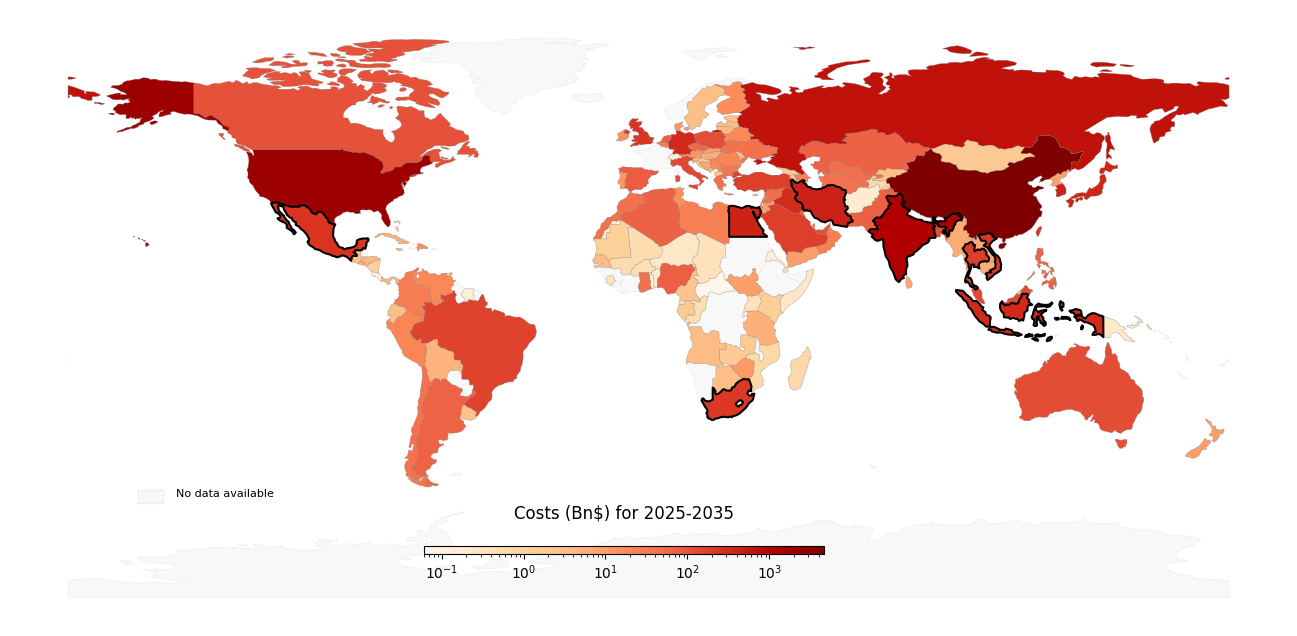

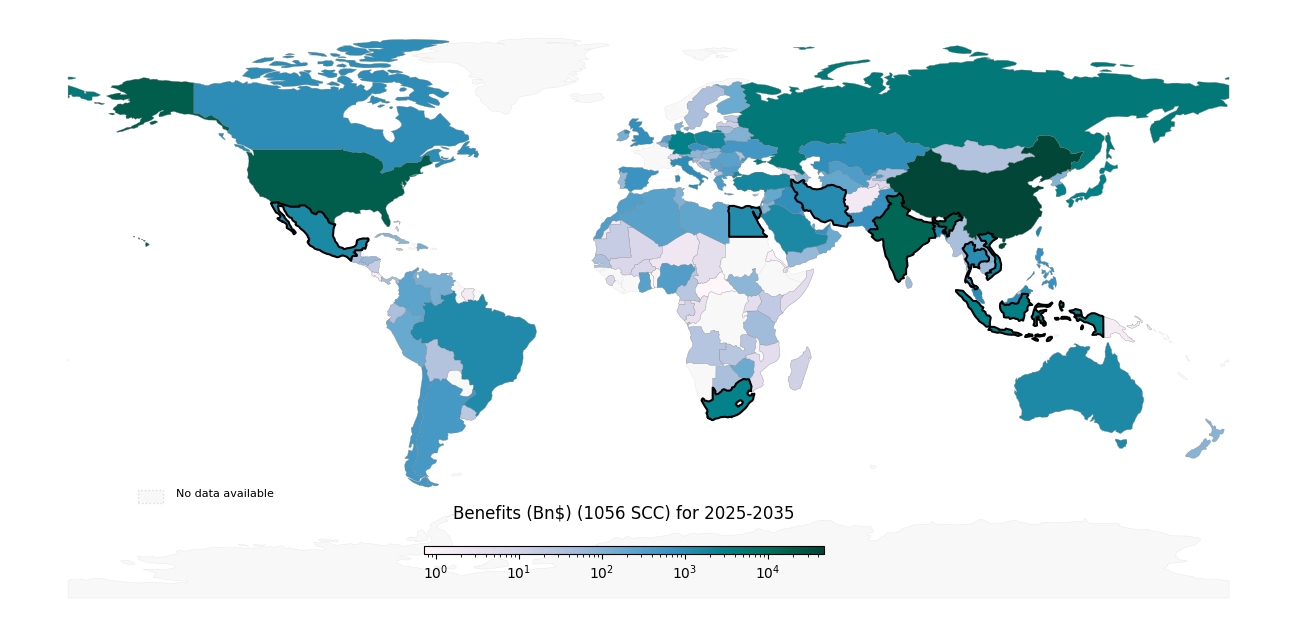

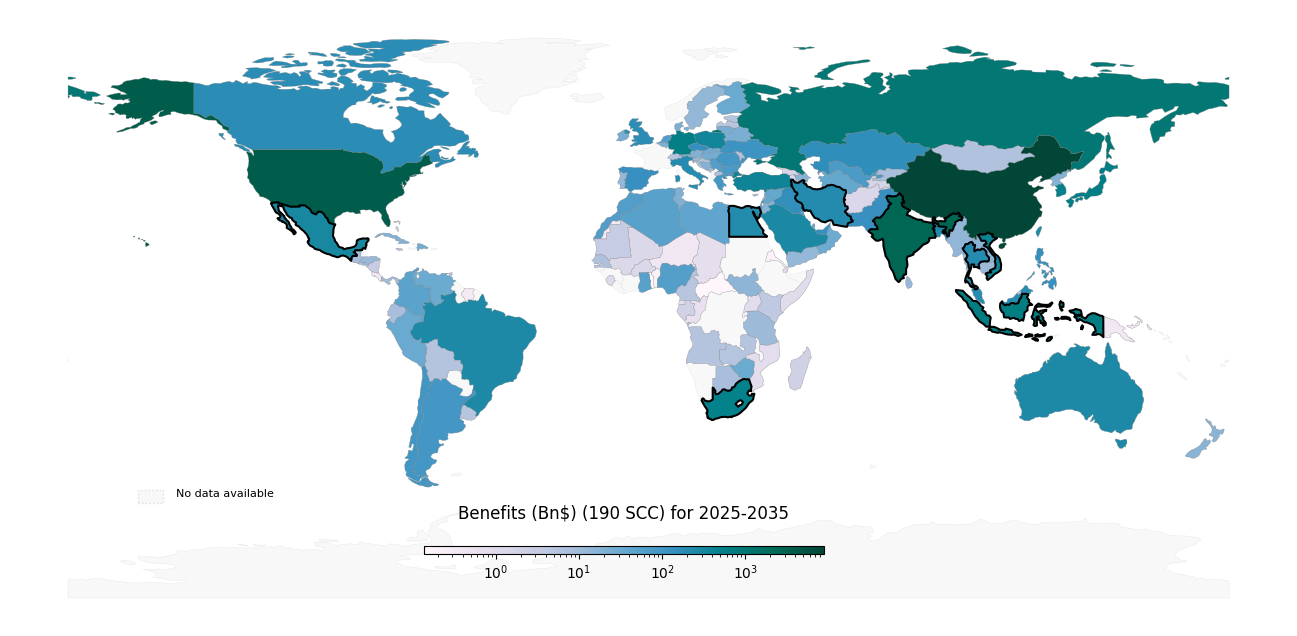

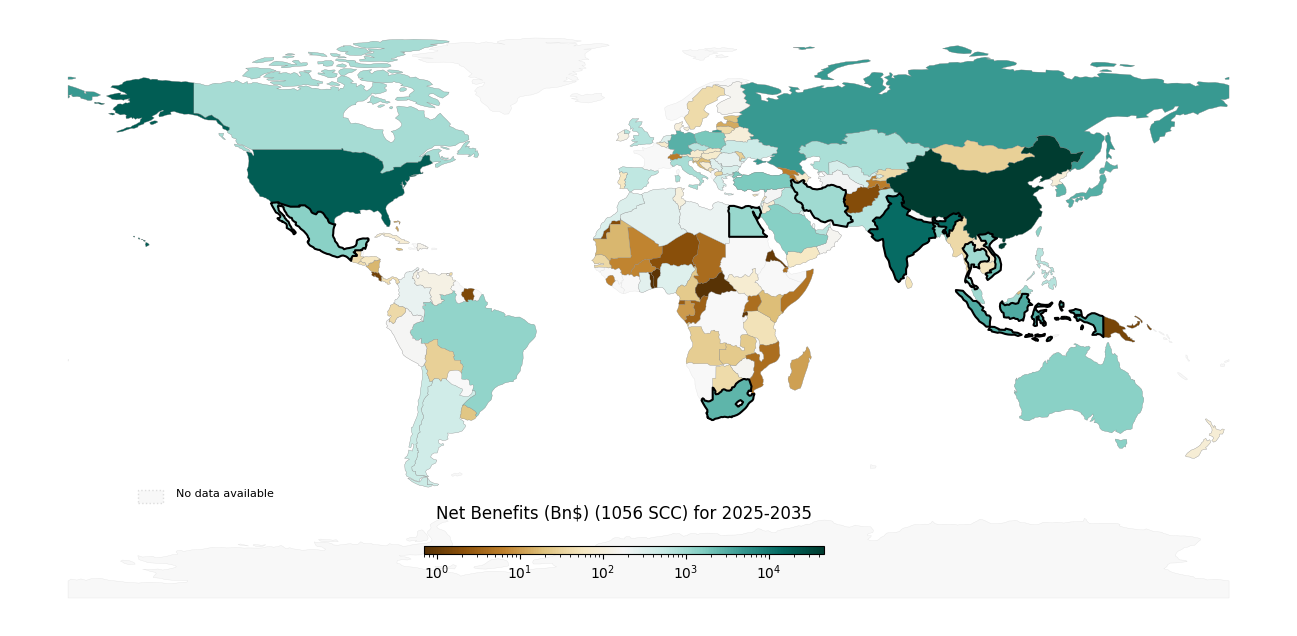

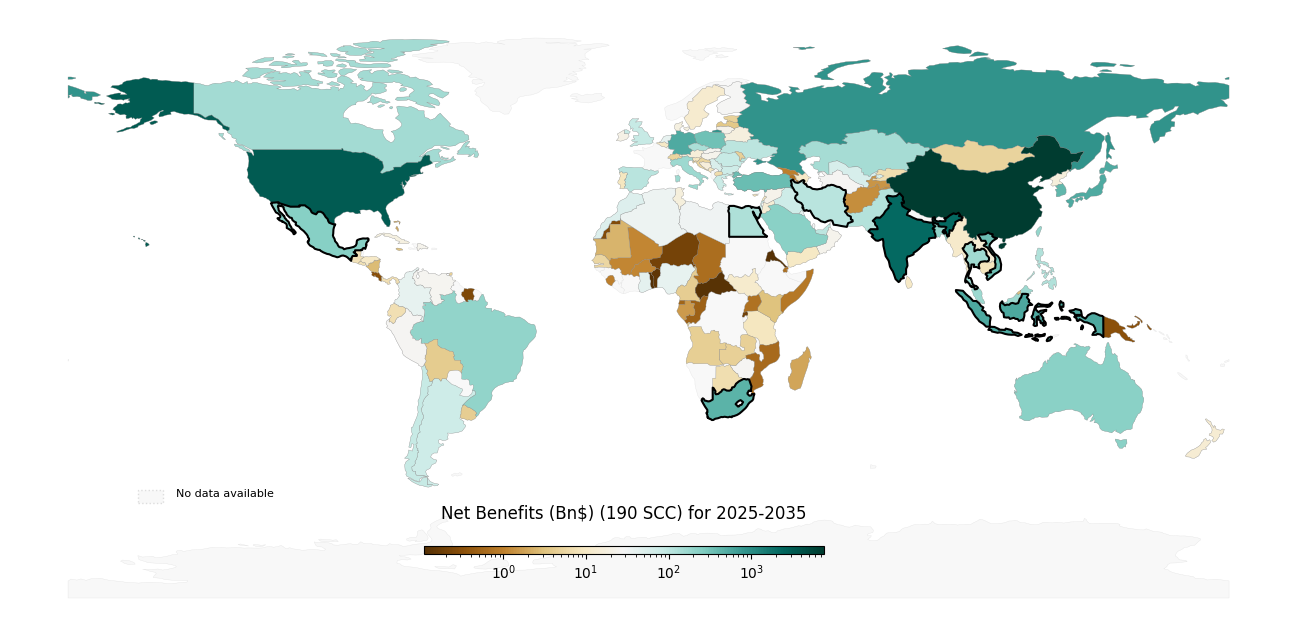

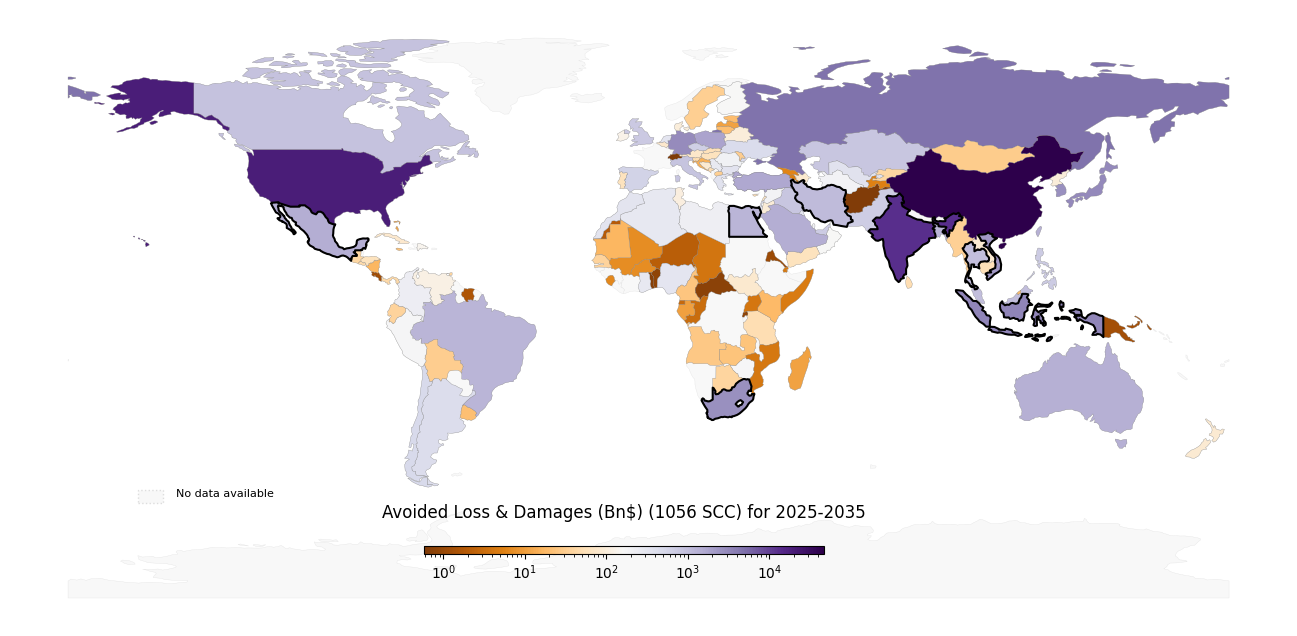

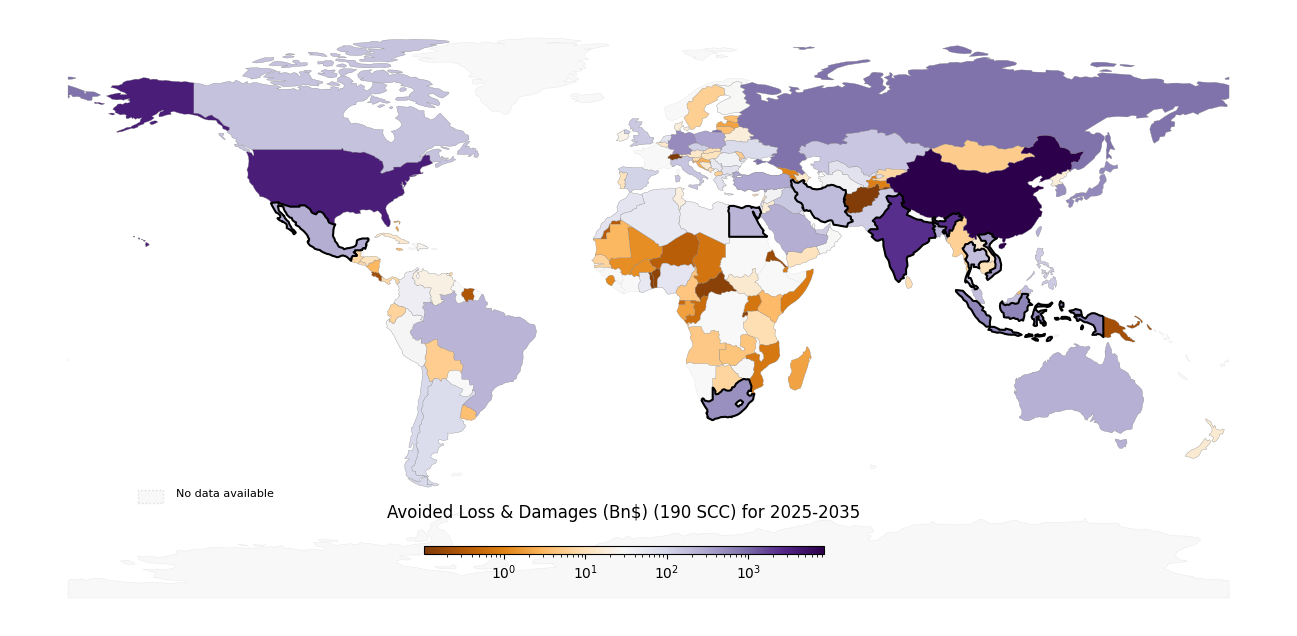

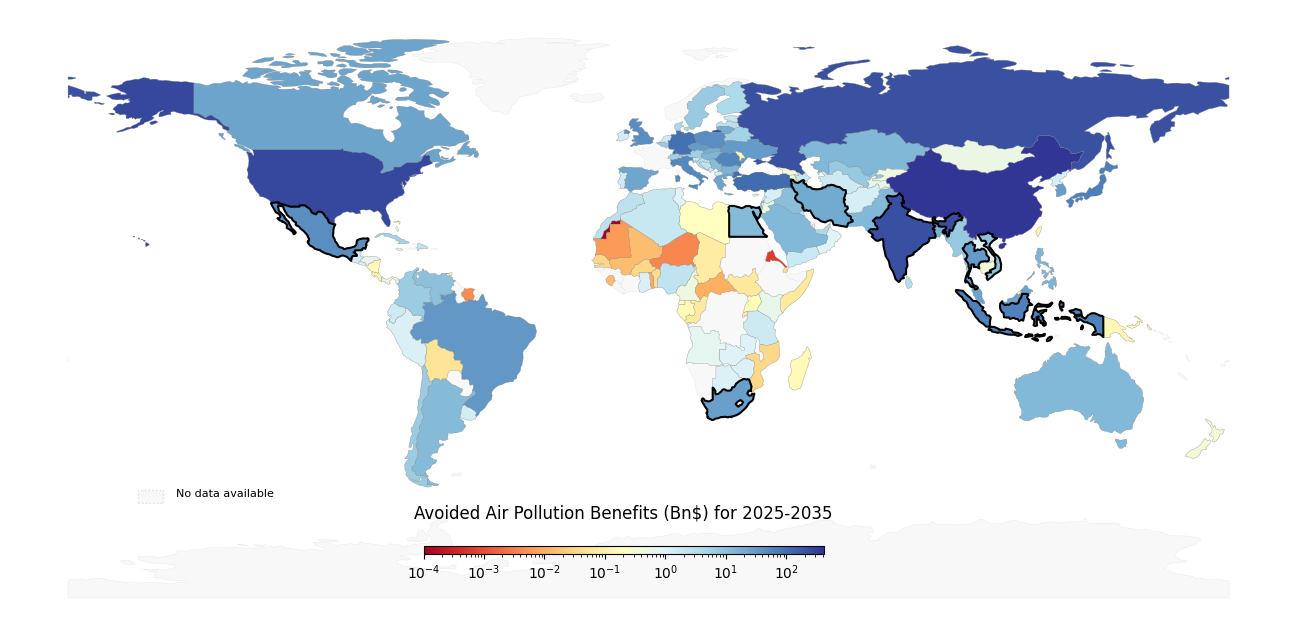

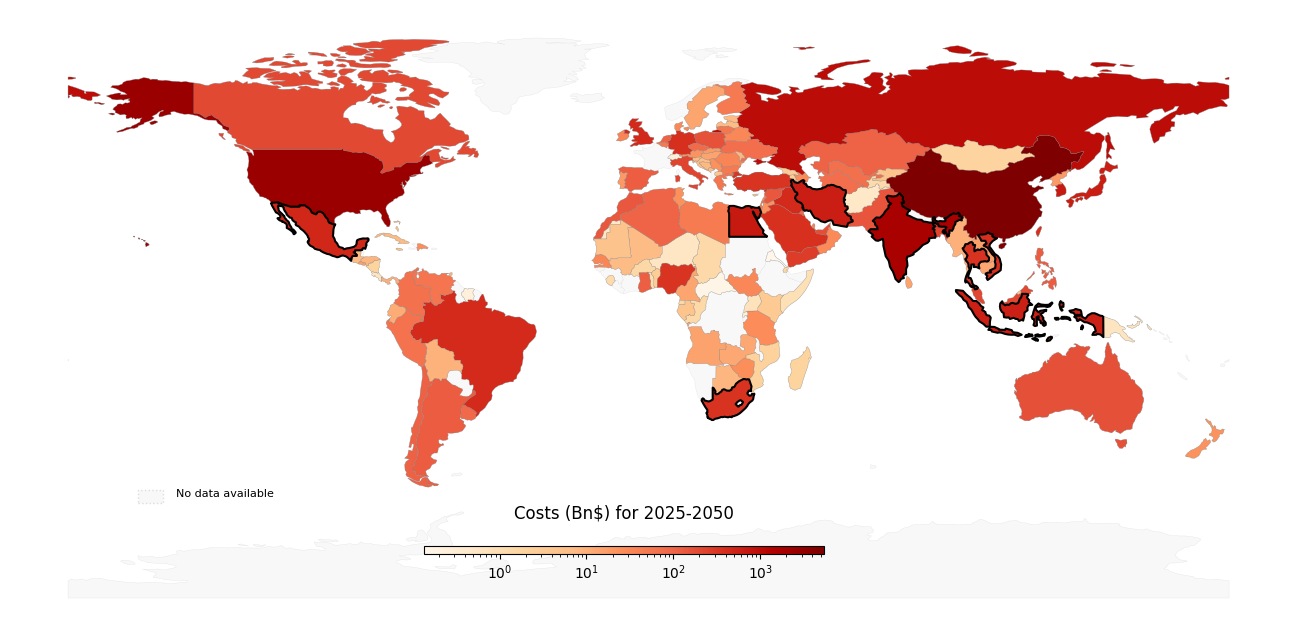

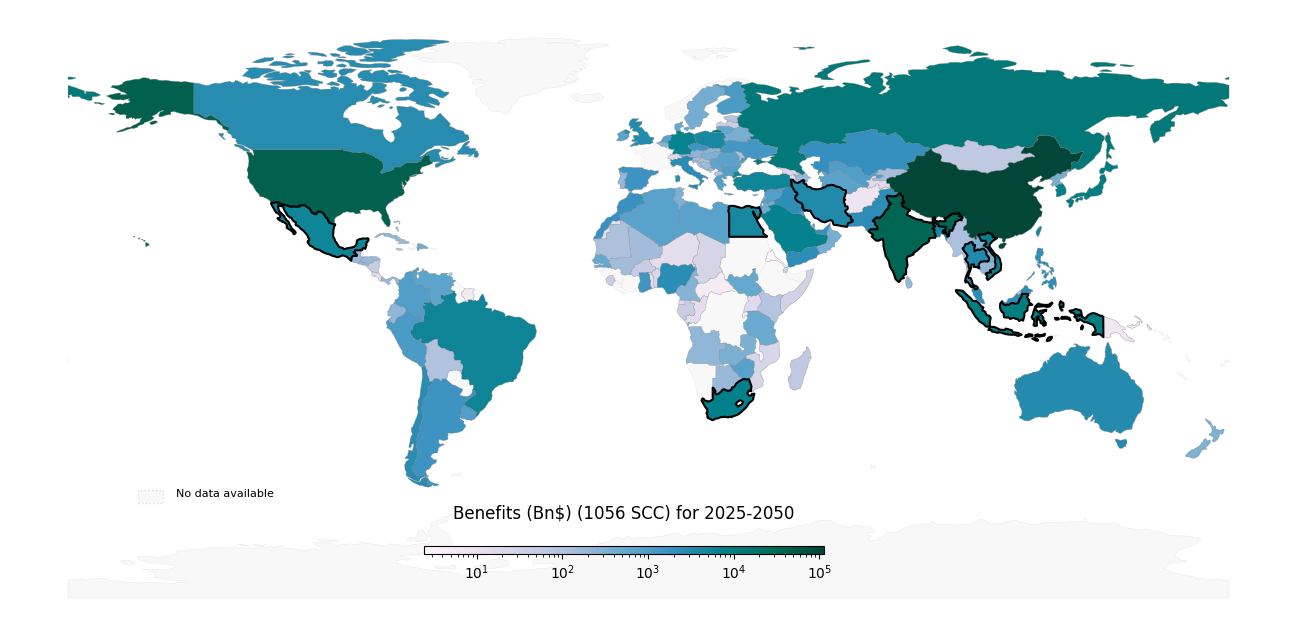

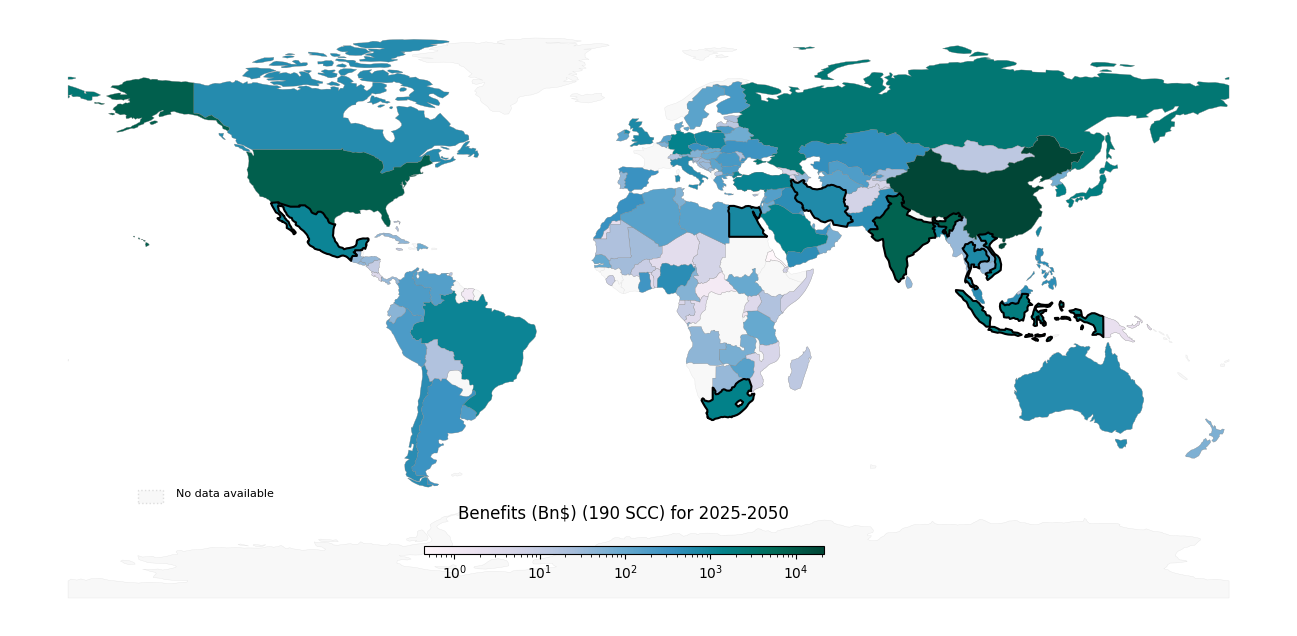

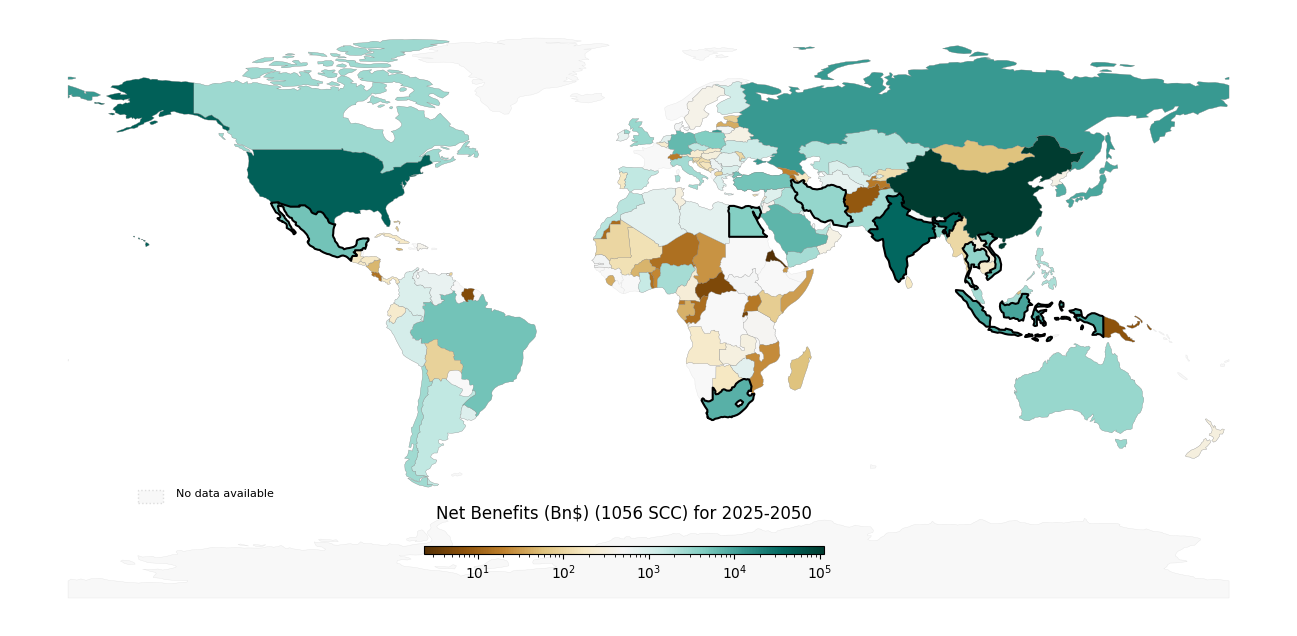

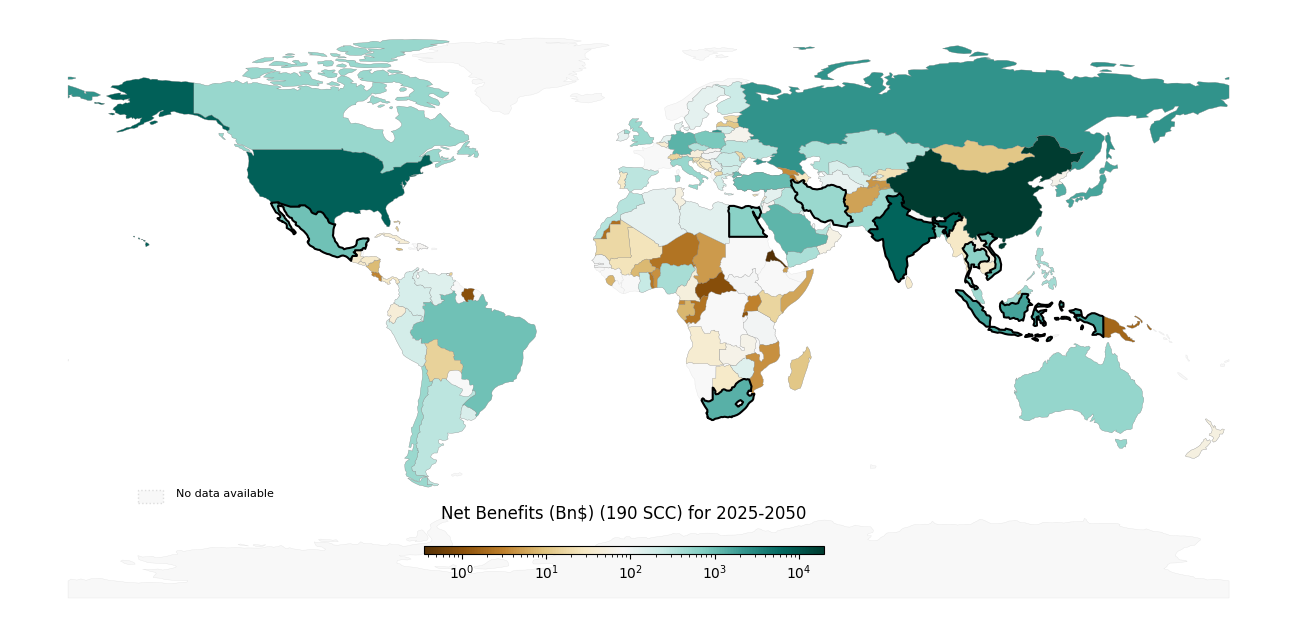

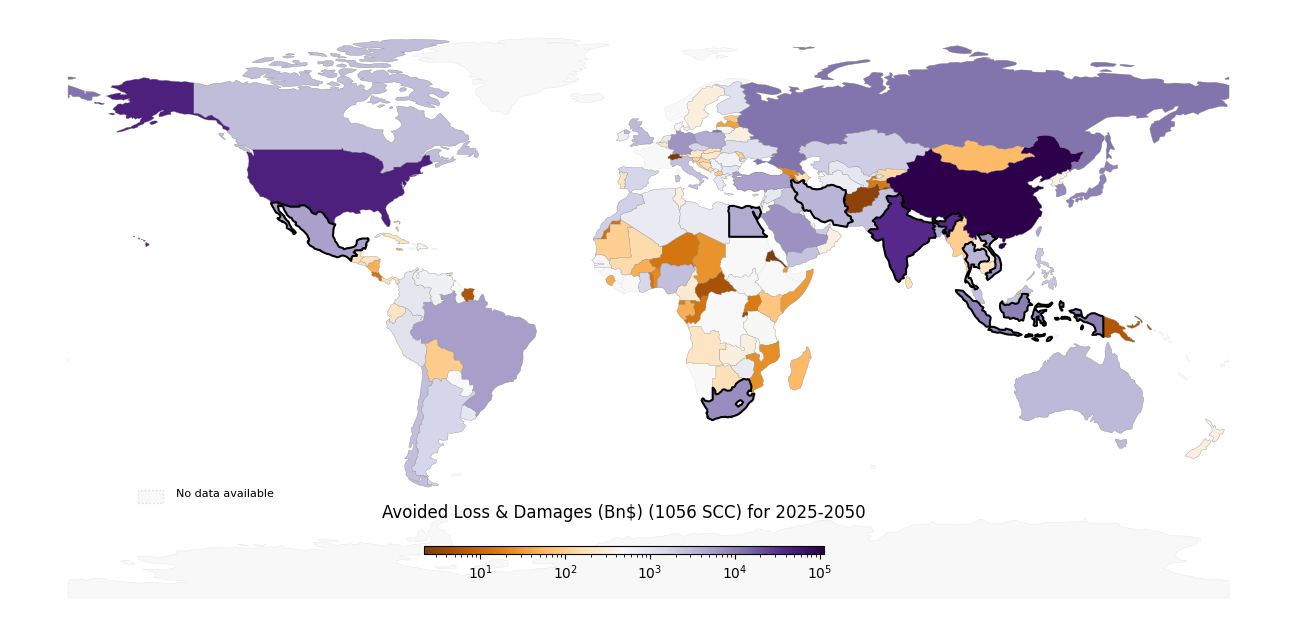

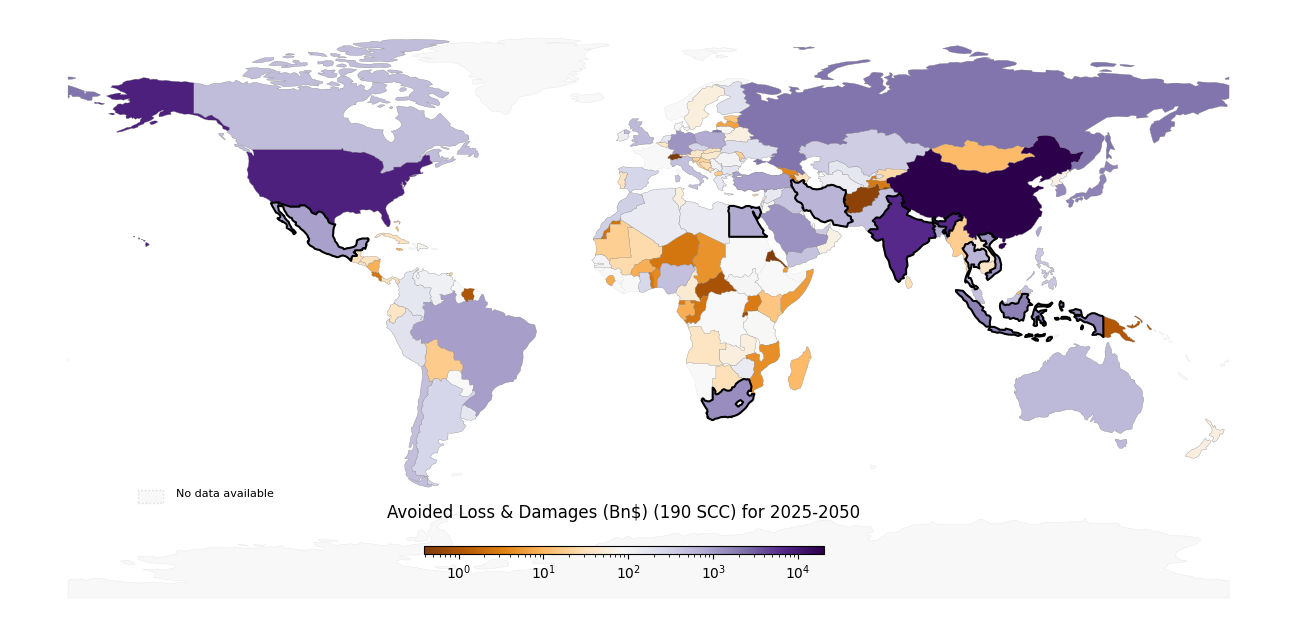

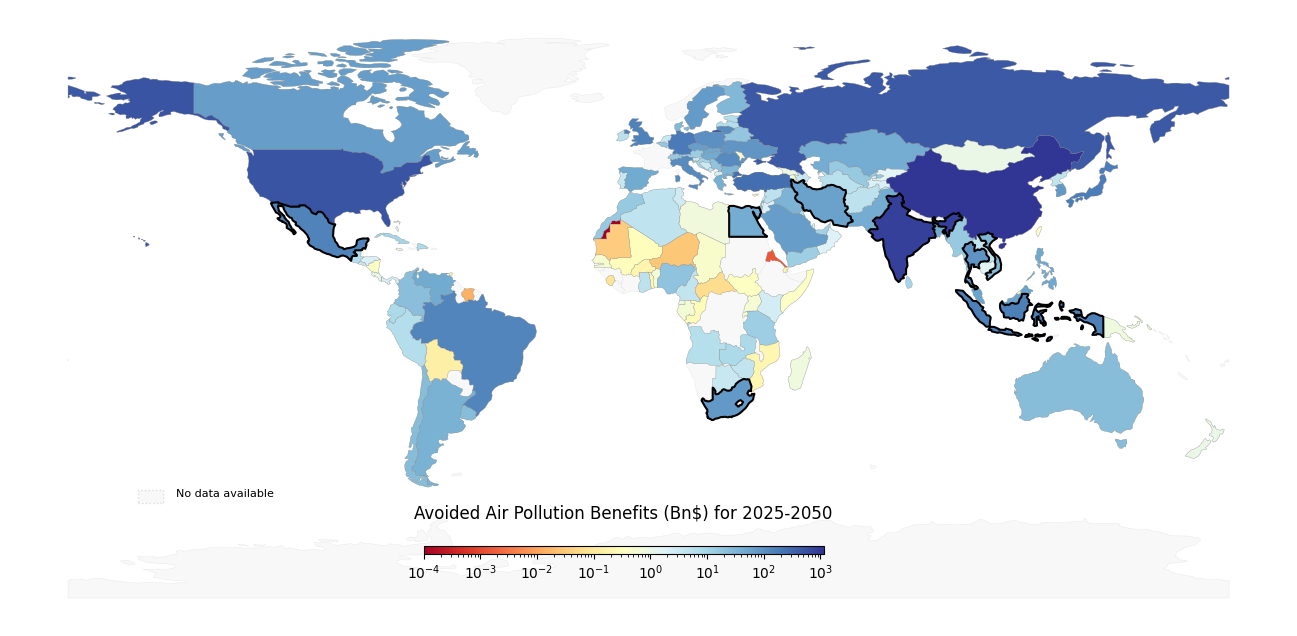

In [10]:
if __name__ == "__main__":
    generate_decarb_maps()